Saving Hybrid_Excess_Condition.csv to Hybrid_Excess_Condition (1).csv


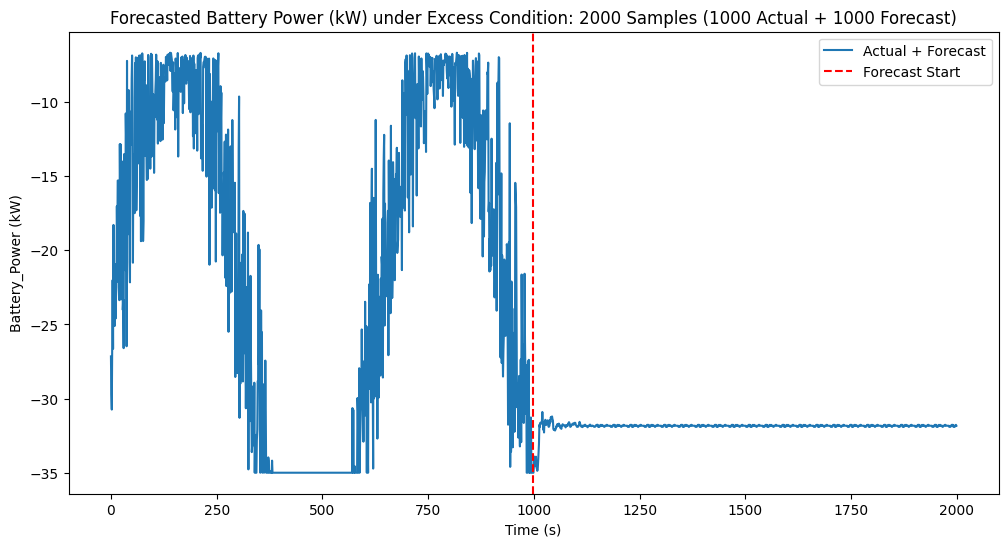

In [ ]:
# ==============================
# 1️⃣ Upload File (Colab Only)
# ==============================
from google.colab import files
uploaded = files.upload()

# ==============================
# 2️⃣ Import Libraries
# ==============================
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ==============================
# 3️⃣ Load Dataset
# ==============================
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# ==============================
# 4️⃣ Select First 1000 Samples
# ==============================
df_train = df.iloc[:1000].copy()

feature = "Battery_Power (kW)"
lag = 100

# ==============================
# 5️⃣ Create Lag Features
# ==============================
X_train, y_train = [], []

for i in range(lag, len(df_train)):
    X_train.append(df_train[feature].iloc[i-lag:i].values)
    y_train.append(df_train[feature].iloc[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

# ==============================
# 6️⃣ Scale Data
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# ==============================
# 7️⃣ Train XGBoost Model
# ==============================
model = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# 8️⃣ Forecast Next 1000 Samples
# ==============================
last_window = df_train[feature].iloc[-lag:].values
future_predictions = []

for _ in range(1000):

    input_scaled = scaler.transform(last_window.reshape(1, -1))
    next_pred = model.predict(input_scaled)[0]

    future_predictions.append(next_pred)

    # Correct recursive update
    last_window = np.append(last_window[1:], next_pred)

# ==============================
# 9️⃣ Create Full 2000 Timeline
# ==============================
original_time = df_train["Time (s)"]
future_time = np.arange(1000, 2000)

combined_time = np.concatenate([original_time, future_time])
combined_values = np.concatenate([df_train[feature], future_predictions])

# ==============================
# 🔟 Plot Results
# ==============================
plt.figure(figsize=(12,6))
plt.plot(combined_time, combined_values, label="Actual + Forecast")
plt.axvline(x=999, color='r', linestyle='--', label='Forecast Start')
plt.xlabel("Time (s)")
plt.ylabel(feature)
plt.legend()
plt.title("Forecasted Battery Power (kW) under Excess Condition: 2000 Samples (1000 Actual + 1000 Forecast)")
plt.show()


Saving Hybrid_Excess_Condition.csv to Hybrid_Excess_Condition (3).csv


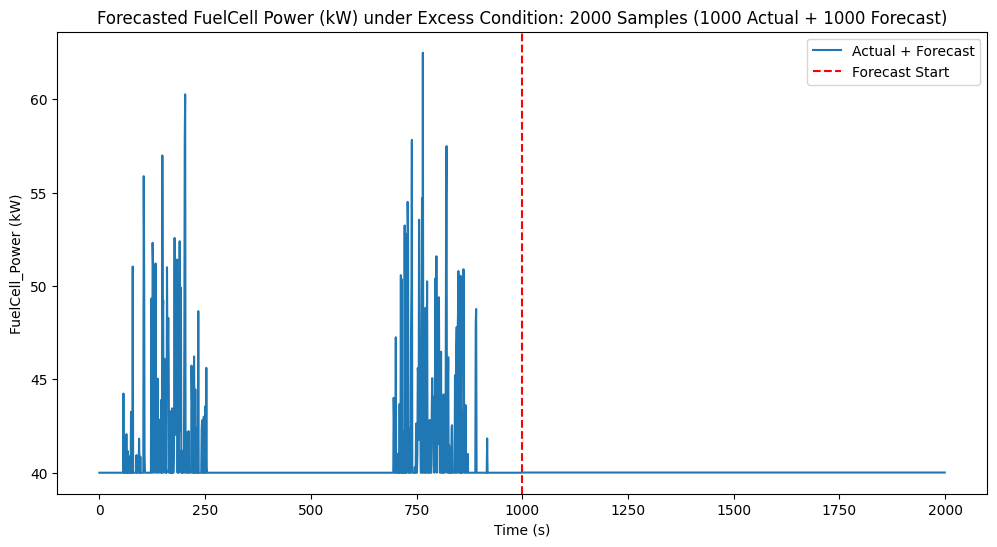

In [ ]:
# ==============================
# 1️⃣ Upload File (Colab Only)
# ==============================
from google.colab import files
uploaded = files.upload()

# ==============================
# 2️⃣ Import Libraries
# ==============================
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# ==============================
# 3️⃣ Load Dataset
# ==============================
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# ==============================
# 4️⃣ Select First 1000 Samples
# ==============================
df_train = df.iloc[:1000].copy()

feature = "FuelCell_Power (kW)"
lag = 100

# ==============================
# 5️⃣ Create Lag Features
# ==============================
X_train, y_train = [], []

for i in range(lag, len(df_train)):
    X_train.append(df_train[feature].iloc[i-lag:i].values)
    y_train.append(df_train[feature].iloc[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

# ==============================
# 6️⃣ Scale Data
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# ==============================
# 7️⃣ Train XGBoost Model
# ==============================
model = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

# ==============================
# 8️⃣ Forecast Next 1000 Samples
# ==============================
last_window = df_train[feature].iloc[-lag:].values
future_predictions = []

for _ in range(1000):

    input_scaled = scaler.transform(last_window.reshape(1, -1))
    next_pred = model.predict(input_scaled)[0]

    future_predictions.append(next_pred)

    # Correct recursive update
    last_window = np.append(last_window[1:], next_pred)

# ==============================
# 9️⃣ Create Full 2000 Timeline
# ==============================
original_time = df_train["Time (s)"]
future_time = np.arange(1000, 2000)

combined_time = np.concatenate([original_time, future_time])
combined_values = np.concatenate([df_train[feature], future_predictions])

# ==============================
# 🔟 Plot Results
# ==============================
plt.figure(figsize=(12,6))
plt.plot(combined_time, combined_values, label="Actual + Forecast")
plt.axvline(x=999, color='r', linestyle='--', label='Forecast Start')
plt.xlabel("Time (s)")
plt.ylabel(feature)
plt.legend()
plt.title("Forecasted FuelCell Power (kW) under Excess Condition: 2000 Samples (1000 Actual + 1000 Forecast)")
plt.show()
